In [18]:
import numpy as np
import pandas
import dpluspy
import moments
import demes

In [4]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=9)
matplotlib.rc("ytick", labelsize=9)
matplotlib.rc("axes", labelsize=9)
matplotlib.rc("axes", titlesize=9)
matplotlib.rc("legend", fontsize=7)
plt.rcParams['legend.title_fontsize'] = 'small'

In [13]:
dfs = []

for rep in range(10):
    df = pandas.read_csv(f"results/ghost_den_fit_null_{rep}.csv")
    best_fit = df[df["ll"] == np.max(df["ll"])]
    best_fit = best_fit.assign(model=f"rep{rep}")
    dfs.append(best_fit)

for model in range(693):
    try:
        df = pandas.read_csv(f"results/ghost_den_fit_{model}.csv")
        best_fit = df[df["ll"] == np.max(df["ll"])]
        best_fit = best_fit.assign(model=model)
        dfs.append(best_fit)
    except:
        print(f"missing fit {model}")
df = pandas.concat(dfs)
df.to_csv("best_fits.csv", index=False)

missing fit 0
missing fit 6
missing fit 21
missing fit 26
missing fit 31
missing fit 36
missing fit 37
missing fit 40
missing fit 43
missing fit 59
missing fit 60
missing fit 92
missing fit 112
missing fit 115
missing fit 134
missing fit 137
missing fit 146
missing fit 149
missing fit 154
missing fit 162
missing fit 177
missing fit 185
missing fit 193
missing fit 194
missing fit 199
missing fit 226
missing fit 230
missing fit 232
missing fit 240
missing fit 246
missing fit 261
missing fit 267
missing fit 287
missing fit 324
missing fit 337
missing fit 363
missing fit 389
missing fit 464
missing fit 517
missing fit 546
missing fit 549
missing fit 565
missing fit 569
missing fit 582
missing fit 620
missing fit 621
missing fit 634
missing fit 641
missing fit 681


In [16]:
df[np.isnan(df["T_Gho"])]

,ll,T_NDH,T_ND,T_AMH_Alt,p_AMH_Alt,N_Anc,N_Yor,N_ND,N_Den,N_Alt,m_AltDen,model,T_Gho,T_Gho_Den,p_Gho_Den,N_Gho
4,-32.885227,770745.666083,727910.255340,360778.202710,0.139146,16388.355908,27245.458294,1647.307029,3432.182113,2307.709220,0.000007,rep0,NaN,NaN,NaN,NaN
7,-31.734453,790249.088415,768982.597102,349224.300277,0.132479,16088.928717,27775.061930,806.431687,3456.725490,2252.773683,0.000008,rep1,NaN,NaN,NaN,NaN
12,-31.708961,789711.890992,773951.545217,346893.517766,0.131400,16093.178768,27756.300888,597.009479,3461.308138,2238.637866,0.000008,rep2,NaN,NaN,NaN,NaN
1,-32.027198,803434.319872,774268.438970,349160.226616,0.130886,15880.865177,28128.973207,1105.137122,3454.757925,2249.725484,0.000008,rep3,NaN,NaN,NaN,NaN
5,-31.917662,792585.349377,756100.436149,349462.356864,0.132039,16048.546811,27838.378958,1394.804307,3450.453667,2262.459431,0.000008,rep4,NaN,NaN,NaN,NaN
1,-31.776895,778864.481645,763492.609907,345936.116027,0.132140,16260.804349,27459.995814,584.481608,3465.062366,2243.261540,0.000008,rep5,NaN,NaN,NaN,NaN
7,-32.025960,791154.074445,748886.305328,348133.479548,0.132060,16071.409572,27799.380867,1624.901351,3437.132987,2253.329863,0.000008,rep6,NaN,NaN,NaN,NaN
0,-33.234196,756185.542216,733502.803263,342495.343301,0.133468,16611.571800,26832.411604,871.647901,3468.900375,2254.708641,0.000007,rep7,NaN,NaN,NaN,NaN
0,-32.395789,797022.968878,743839.561480,359114.618460,0.136206,15980.608585,27957.073104,2064.978470,3370.727730,2243.365256,0.000008,rep8,NaN,NaN,NaN,NaN
11,-31.890386,787412.340789,779780.122015,337578.312825,0.127573,16127.188600,27691.695303,288.749749,3472.890083,2206.784203,0.000008,rep9,NaN,NaN,NaN,NaN


In [17]:
df[df["ll"] == np.max(df["ll"])]

,ll,T_NDH,T_ND,T_AMH_Alt,p_AMH_Alt,N_Anc,N_Yor,N_ND,N_Den,N_Alt,m_AltDen,model,T_Gho,T_Gho_Den,p_Gho_Den,N_Gho
1,-31.000135,771680.711793,744571.523775,321317.839576,0.117339,16342.390073,27339.56063,1002.333063,3431.360527,2352.322787,0.000005,165,1.821914e+06,90000.000001,0.001485,50000.0


In [31]:
lls = {}
for model in range(693):
    fname = f"results/ghost_den_fit_{model}.yaml"
    g = demes.load(fname)
    lls[fname] = g.metadata["opt_info"]["ll"]
max_ll_fname = "x"
max_ll = -1000
for fname in lls:
    if lls[fname] > max_ll:
        max_ll_fname = fname
        max_ll = lls[fname]
print(max_ll, max_ll_fname)

-31.496862403247924 results/ghost_den_fit_167.yaml


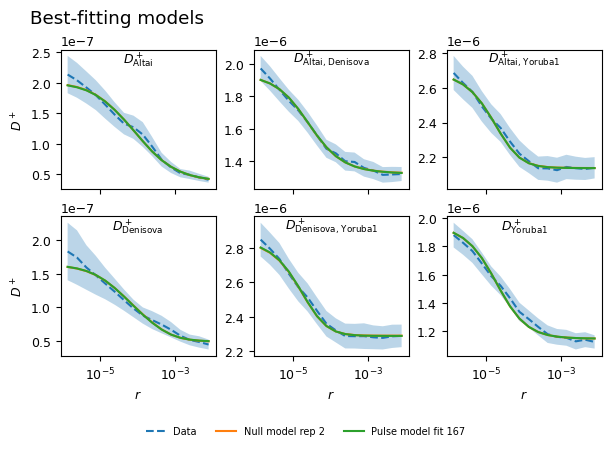

In [35]:
u = 1.3e-8
graph0 = "results/ghost_den_fit_null_2.yaml"
graph1 = "results/ghost_den_fit_167.yaml"
data_file = "../../../../analyses/recombination_maps/stats/subset_Bherer.pkl"
data = dpluspy.inference.load_stats(
    data_file, graph=graph0, return_dict=True)
model0 = dpluspy.inference.compute_bin_stats(graph0, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model1 = dpluspy.inference.compute_bin_stats(graph1, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
dpluspy.plotting.plot_D_plus_curves(
    models=[model0, model1],
    pop_ids=data["pop_ids"], 
    bins=data["bins"], 
    means=data["means"], 
    varcovs=data["varcovs"], 
    labels=["Data", "Null model rep 2", "Pulse model fit 167"],
    title="Best-fitting models",
    out="figures/best_fit_model.pdf",
    cols=3
)